Using Colab cache for faster access to the 'housing-price-prediction' dataset.
Dataset Path:
/kaggle/input/housing-price-prediction

Files in Dataset Folder:
['Housing.csv']

First 5 Rows:
      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes 

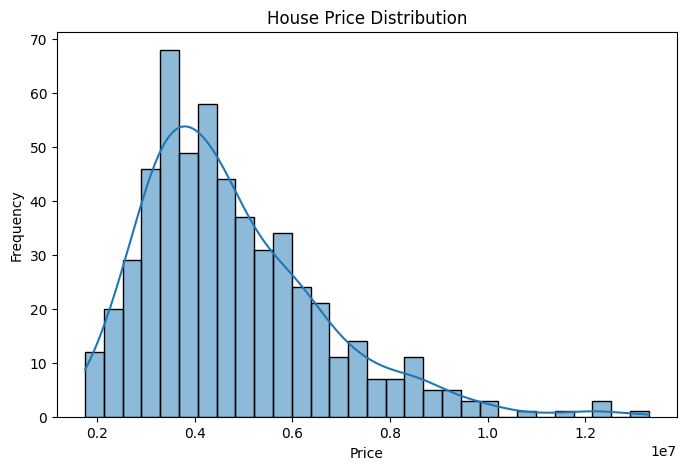

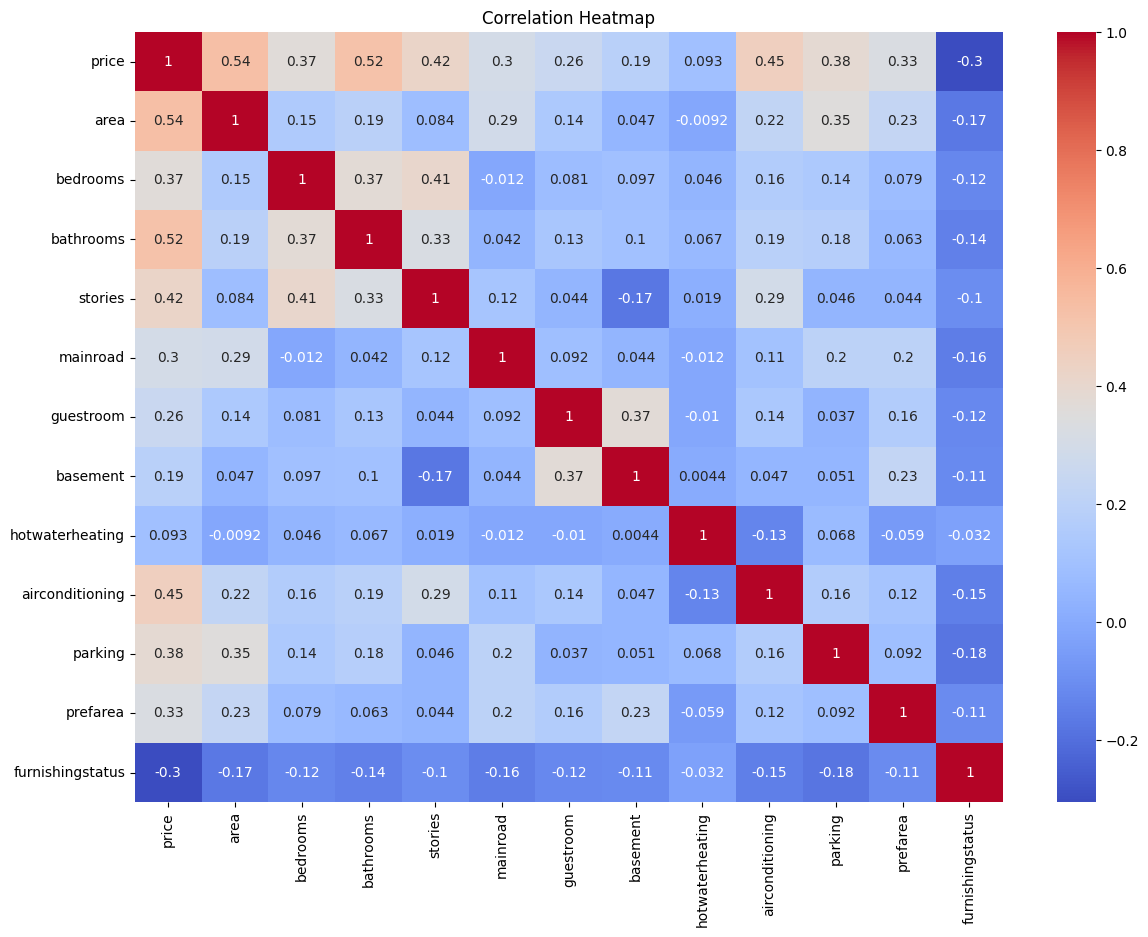


Mean Absolute Error (MAE):
962791.7251720891

Root Mean Squared Error (RMSE):
1301972.2177151316


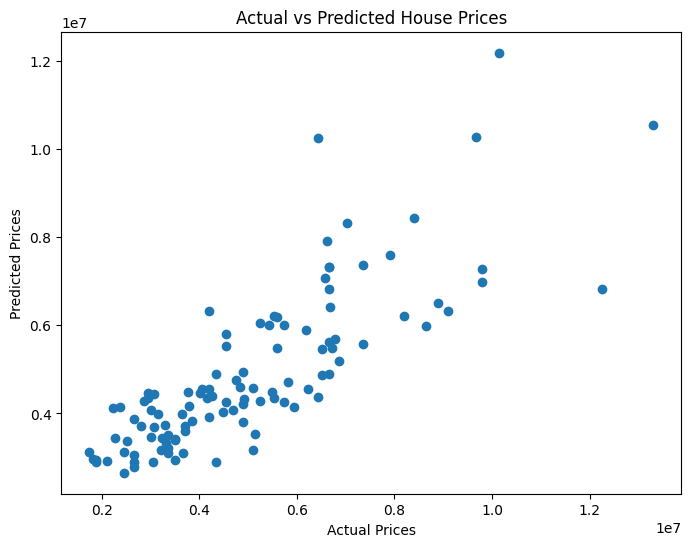


Feature Importance:
             Feature  Importance
0               area    0.461064
2          bathrooms    0.167053
8    airconditioning    0.090971
9            parking    0.052063
3            stories    0.045940
1           bedrooms    0.045634
11  furnishingstatus    0.032058
6           basement    0.031741
10          prefarea    0.026809
4           mainroad    0.016712
7    hotwaterheating    0.015354
5          guestroom    0.014601


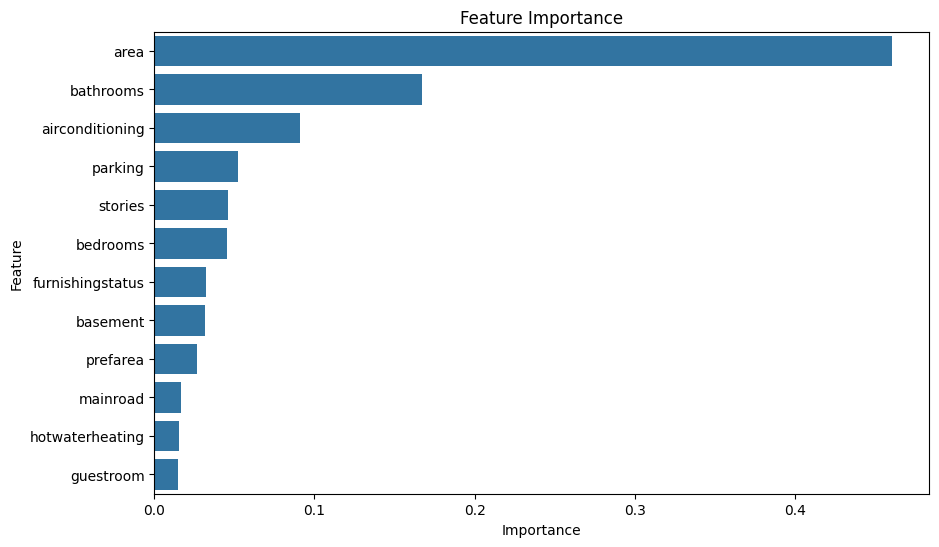


Final Insights:
1. Gradient Boosting performed effectively.
2. Property area and number of rooms highly affect prices.
3. The model predicts house prices with good accuracy.
4. Feature importance reveals major pricing factors.


In [6]:
# ===================================================
# TASK 6 - HOUSE PRICE PREDICTION
# ===================================================

# ===================================================
# IMPORT LIBRARIES
# ===================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import GradientBoostingRegressor

# ===================================================
# DOWNLOAD DATASET
# ===================================================

path = kagglehub.dataset_download(
    "harishkumardatalab/housing-price-prediction"
)

print("Dataset Path:")
print(path)

# Show files
print("\nFiles in Dataset Folder:")
print(os.listdir(path))

# ===================================================
# LOAD DATASET
# ===================================================

# Change filename if different
df = pd.read_csv(os.path.join(path, "Housing.csv"))

# ===================================================
# BASIC INFORMATION
# ===================================================

print("\nFirst 5 Rows:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nDataset Info:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe())

# ===================================================
# CHECK MISSING VALUES
# ===================================================

print("\nMissing Values:")
print(df.isnull().sum())

# ===================================================
# HANDLE CATEGORICAL FEATURES
# ===================================================

label_encoder = LabelEncoder()

categorical_columns = df.select_dtypes(
    include=['object']
).columns

for col in categorical_columns:
    df[col] = label_encoder.fit_transform(df[col])

# ===================================================
# DATA VISUALIZATION
# ===================================================

# Price Distribution
plt.figure(figsize=(8,5))

sns.histplot(df['price'], bins=30, kde=True)

plt.title("House Price Distribution")

plt.xlabel("Price")
plt.ylabel("Frequency")

plt.show()

# Correlation Heatmap
plt.figure(figsize=(14,10))

sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

# ===================================================
# FEATURE & TARGET SPLIT
# ===================================================

X = df.drop('price', axis=1)
y = df['price']

# ===================================================
# TRAIN TEST SPLIT
# ===================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# ===================================================
# MODEL TRAINING
# ===================================================

model = GradientBoostingRegressor()

model.fit(X_train, y_train)

# ===================================================
# PREDICTIONS
# ===================================================

y_pred = model.predict(X_test)

# ===================================================
# MODEL EVALUATION
# ===================================================

mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("\nMean Absolute Error (MAE):")
print(mae)

print("\nRoot Mean Squared Error (RMSE):")
print(rmse)

# ===================================================
# ACTUAL VS PREDICTED VISUALIZATION
# ===================================================

plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")

plt.title("Actual vs Predicted House Prices")

plt.show()

# ===================================================
# FEATURE IMPORTANCE
# ===================================================

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print("\nFeature Importance:")
print(importance)

# Visualization
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)

plt.title("Feature Importance")

plt.show()

# ===================================================
# FINAL INSIGHTS
# ===================================================

print("\nFinal Insights:")
print("1. Gradient Boosting performed effectively.")
print("2. Property area and number of rooms highly affect prices.")
print("3. The model predicts house prices with good accuracy.")
print("4. Feature importance reveals major pricing factors.")